In [4]:
!pip install deap

In [7]:
import random
import numpy as np
from deap import base, creator, tools, algorithms

# Define the optimization problem as minimization
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

LOW =  [-5, 0, 1]   # Minimum bounds for variables
HIGH = [ 5, 5, 3]   # Maximum bounds for variables
N_VAR = len(LOW)

# Define the toolbox
toolbox = base.Toolbox()
# Variable 1: Continuous variable
toolbox.register("attr_float1", random.uniform, LOW[0], HIGH[0])

# Variable 2: Continuous variable
toolbox.register("attr_float2", random.uniform, LOW[1], HIGH[1])

# Variable 3: Discrete variable from the set {1, 2, 3}
toolbox.register("attr_int", random.choice, range(LOW[2], HIGH[2], 1)) # (start, stop, step)
# range(3, 6)  ===> [3,4,5]    step is 1 by default

# Combine variables into an individual
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_float1, toolbox.attr_float2, toolbox.attr_int), n=1)
# n=1, it means that each of the attribute generators in the provided tuple
# (toolbox.attr_float1, toolbox.attr_float2, toolbox.attr_int)
# will be called exactly once to populate the individual's attributes.

# Define the population
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_function(individual): # Define the objective function
    x1, x2, x3 = individual
    return ((x1 - 4) ** 2 + (x2 - 2.35) ** 2 + (x3 - 2) ** 2,)

toolbox.register("evaluate", eval_function)

# Define genetic operators
toolbox.register("mate", tools.cxBlend, alpha=0.5)  # Blend crossover for continuous variables
toolbox.register("mutate_cont", tools.mutGaussian, mu=0, sigma=2, indpb=0.5)  # Continuous mutation
toolbox.register("mutate_int", tools.mutUniformInt, low=LOW[2], up=HIGH[2], indpb=1.0)  # Discrete mutation
toolbox.register("select", tools.selTournament, tournsize=3)

# Custom mutation to handle both continuous and discrete parts
def custom_mutate(individual):
    # Mutate continuous variables (x1 and x2)
    toolbox.mutate_cont(individual[:N_VAR-1])
    # Mutate discrete variable (x3)
    toolbox.mutate_int(individual[N_VAR-1:])
    return individual,

def check_bounds(individual):
    individual[0] = np.clip(individual[0], LOW[0], HIGH[0])
    individual[1] = np.clip(individual[1], LOW[1], HIGH[1])
    individual[2] = np.clip(individual[2], LOW[2], HIGH[2])
    return individual, 0

toolbox.register("mutate", custom_mutate)
toolbox.decorate("mutate", tools.DeltaPenalty(check_bounds, 0))  # Use check_bounds function

# Main algorithm
POP_SZ = 35
def main():
    random.seed(77)

    # Create a population
    population = toolbox.population(n=POP_SZ)

    # Statistics to track
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", min)
    # Extract the fitness value from the tuple for calculating average
    stats.register("avg", lambda lst: sum(x[0] for x in lst) / len(lst))


    # Run the genetic algorithm
    population, logbook = algorithms.eaSimple(population, toolbox,
                                              cxpb=0.7, mutpb=0.2,
                                              ngen=20, stats=stats, verbose=True)
    return population, logbook

if __name__ == "__main__":
    final_population, log = main()

    # Display the best solution
    best_individual = tools.selBest(final_population, k=1)[0]
    print("Best Individual:", best_individual)
    print("Fitness:", best_individual.fitness.values)
    print(f"Final Population with {POP_SZ} individuals - {final_population}")


gen	nevals	min                 	avg    
0  	35    	(0.731796589858632,)	29.6043
1  	26    	(0.12508715083515753,)	6.46309
2  	25    	(0.12531930437809158,)	2.48609
3  	26    	(np.float64(0.07980322256517619),)	1.31502
4  	32    	(np.float64(0.004361364713284981),)	0.434324
5  	25    	(np.float64(0.004361364713284981),)	0.248411
6  	30    	(np.float64(0.004361364713284981),)	0.163102
7  	22    	(np.float64(1.2796651075847062e-05),)	0.0827787
8  	25    	(np.float64(1.2796651075847062e-05),)	0.0249361
9  	25    	(np.float64(0.00023697442631560222),)	0.011632 
10 	26    	(np.float64(0.00023697442631560222),)	0.00882022
11 	28    	(np.float64(0.0003591693280355617),) 	0.0032366 
12 	21    	(np.float64(0.0002806574639759471),) 	0.00190377
13 	21    	(np.float64(0.0002806574639759471),) 	0.000987297
14 	25    	(np.float64(0.00016543931632206758),)	0.000520362
15 	25    	(np.float64(0.0001574033830876743),) 	0.000293266
16 	24    	(np.float64(0.00011407134725163561),)	0.000212176
17 	23    	(n

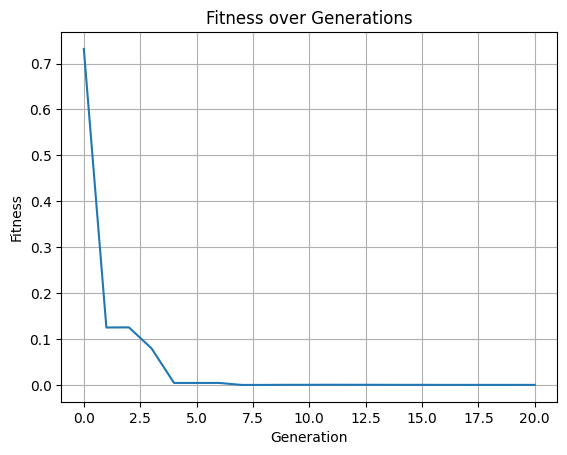

In [6]:
import matplotlib.pyplot as plt

# Assuming 'log' is the logbook from the previous code
gen = log.select("gen")
fit_mins = log.select("min")
fit_avgs = log.select("avg")

plt.plot(gen, fit_mins, label="Minimum Fitness")
#plt.plot(gen, fit_avgs, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Fitness over Generations")
plt.grid(True)
plt.show()